In [1]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
import math

In [2]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })

In [3]:
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

In [4]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Copy of Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("non-control")
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "non-control" else "control method"
)

# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

bio_metrics = [
    'ari',
    'nmi',
    'graph_connectivity',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
]

batch_metrics = [
    'pcr',
    'ilisi',
    'clisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

def categorize_metric(m):
    if m in bio_metrics:
        return "bio"
    if m in batch_metrics:
        return "batch"
    return "baseline"

df["metric_type"] = df["metric_id"].apply(categorize_metric)

In [5]:
baseline = df[df["metric_type"] == "baseline"]
non_baseline = df[df["metric_type"] != "baseline"]

# For non-baseline, the metric_group is just metric_type ("bio" or "batch")
non_baseline = non_baseline.assign(metric_group=non_baseline["metric_type"])

# Duplicate baseline rows: one copy for "bio", one for "batch"
baseline_bio = baseline.copy()
baseline_bio["metric_group"] = "bio"

baseline_batch = baseline.copy()
baseline_batch["metric_group"] = "batch"

# Combine everything
df = pd.concat(
    [non_baseline, baseline_bio, baseline_batch],
    ignore_index=True
)

# with ARI

In [7]:
rows = []

for method, df_m in df.query("metric_id == 'ari' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.060266  0.649050  0.056876
1              combat  6  0.132174  0.473627  0.135022
2             harmony  6  0.160385  0.364443  0.207144
3           harmonypy  6  0.136097  0.336675  0.229256
4               liger  6  0.119241  0.511252  0.114782
5             pyliger  6  0.109033  0.442949  0.153151
6              scalex  6 -0.003660  0.967228  0.000477
7           scanorama  6 -0.046474  0.596281  0.076268
8              scanvi  6  0.271919  0.269319  0.291004
9                scvi  6  0.261822  0.216550  0.349477
10                uce  6  0.177115  0.005297  0.883550


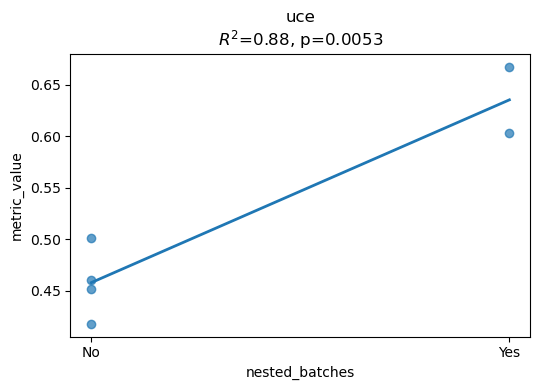

In [11]:
df_metric = df.query("metric_id == 'ari'") 

methods = [
    "uce",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with NMI

In [12]:
rows = []

for method, df_m in df.query("metric_id == 'nmi' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.038805  0.442908  0.153177
1              combat  6  0.056081  0.463133  0.141052
2             harmony  6  0.012369  0.836653  0.011954
3           harmonypy  6  0.033535  0.493123  0.124271
4               liger  6 -0.056662  0.383785  0.192734
5             pyliger  6 -0.039547  0.419263  0.168230
6              scalex  6 -0.072352  0.103011  0.525681
7           scanorama  6 -0.034891  0.743358  0.029865
8              scanvi  6  0.103248  0.352809  0.216196
9                scvi  6  0.100379  0.241941  0.320045
10                uce  6  0.066366  0.049181  0.660978


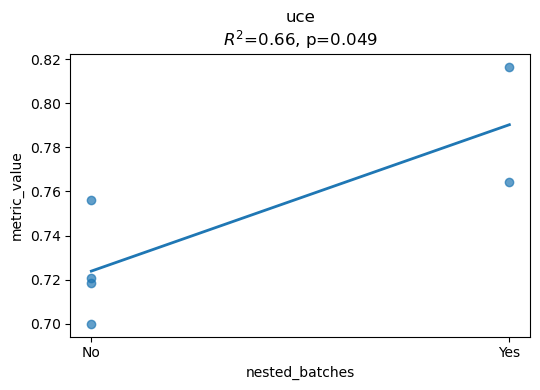

In [13]:
df_metric = df.query("metric_id == 'nmi'") 

methods = [
    "uce",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with graph_connectivity

In [14]:
rows = []

for method, df_m in df.query("metric_id == 'graph_connectivity' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.021265  0.747941  0.028787
1              combat  6  0.012639  0.743000  0.029950
2             harmony  6 -0.021183  0.683533  0.045906
3           harmonypy  6 -0.020004  0.714584  0.037118
4               liger  6 -0.083284  0.623501  0.065861
5             pyliger  6 -0.083386  0.642458  0.059124
6              scalex  6 -0.014544  0.877317  0.006719
7           scanorama  6 -0.034452  0.821403  0.014313
8              scanvi  6  0.030684  0.382488  0.193676
9                scvi  6  0.035119  0.394361  0.185176
10                uce  6  0.032032  0.341378  0.225386


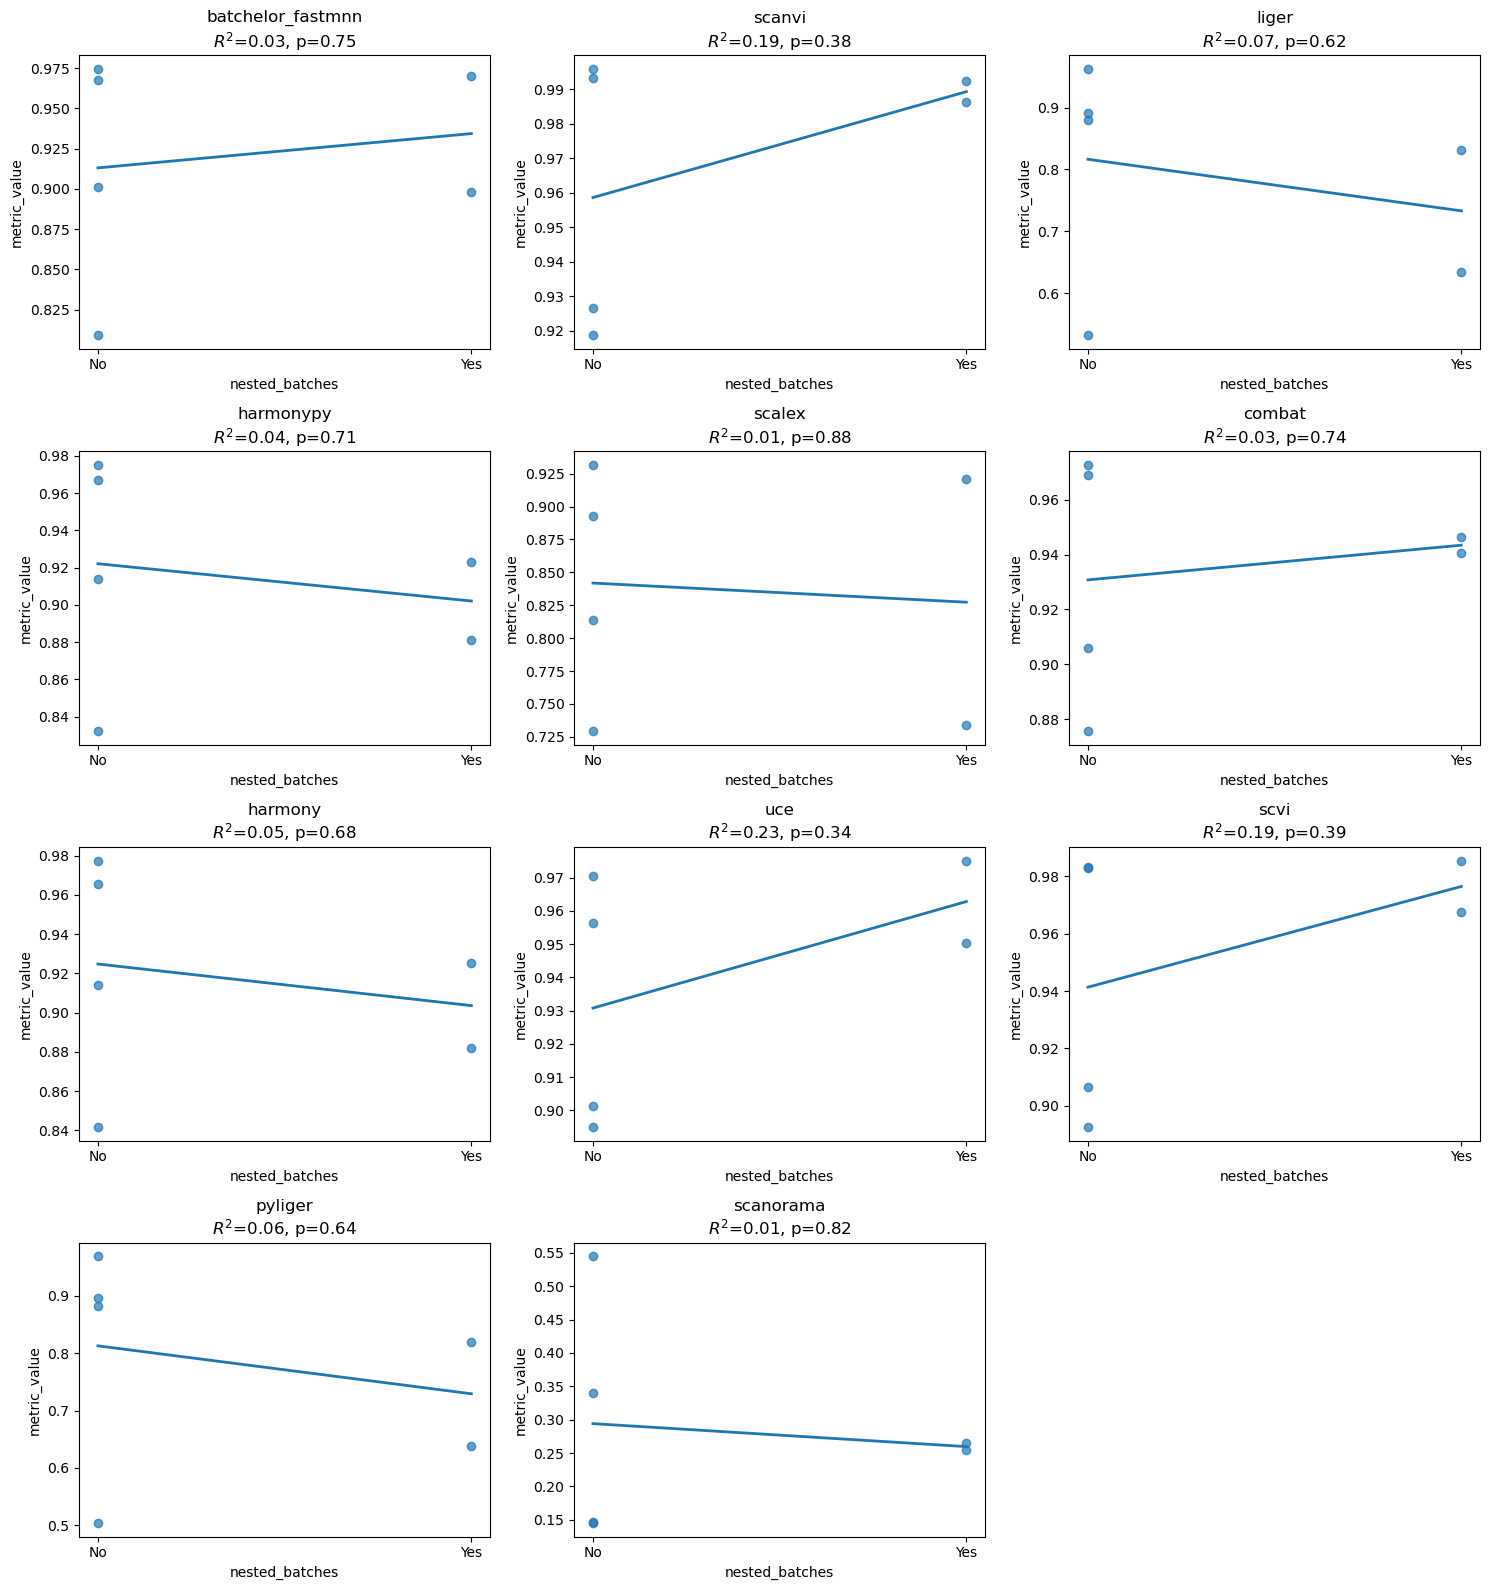

In [16]:
df_metric = df.query("metric_id == 'graph_connectivity'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with cell_cycle_conservation

In [17]:
rows = []

for method, df_m in df.query("metric_id == 'cell_cycle_conservation' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.083583  0.257587  0.303132
1              combat  6  0.026591  0.482485  0.130066
2             harmony  6  0.053656  0.490843  0.125499
3           harmonypy  6  0.047099  0.545048  0.098332
4               liger  6 -0.019883  0.670781  0.049812
5             pyliger  6  0.010787  0.927281  0.002354
6              scalex  6  0.088466  0.478012  0.132553
7           scanorama  6 -0.063554  0.636633  0.061150
8              scanvi  6  0.052215  0.538494  0.101400
9                scvi  6 -0.006429  0.948226  0.001192
10                uce  6  0.012254  0.915162  0.003206


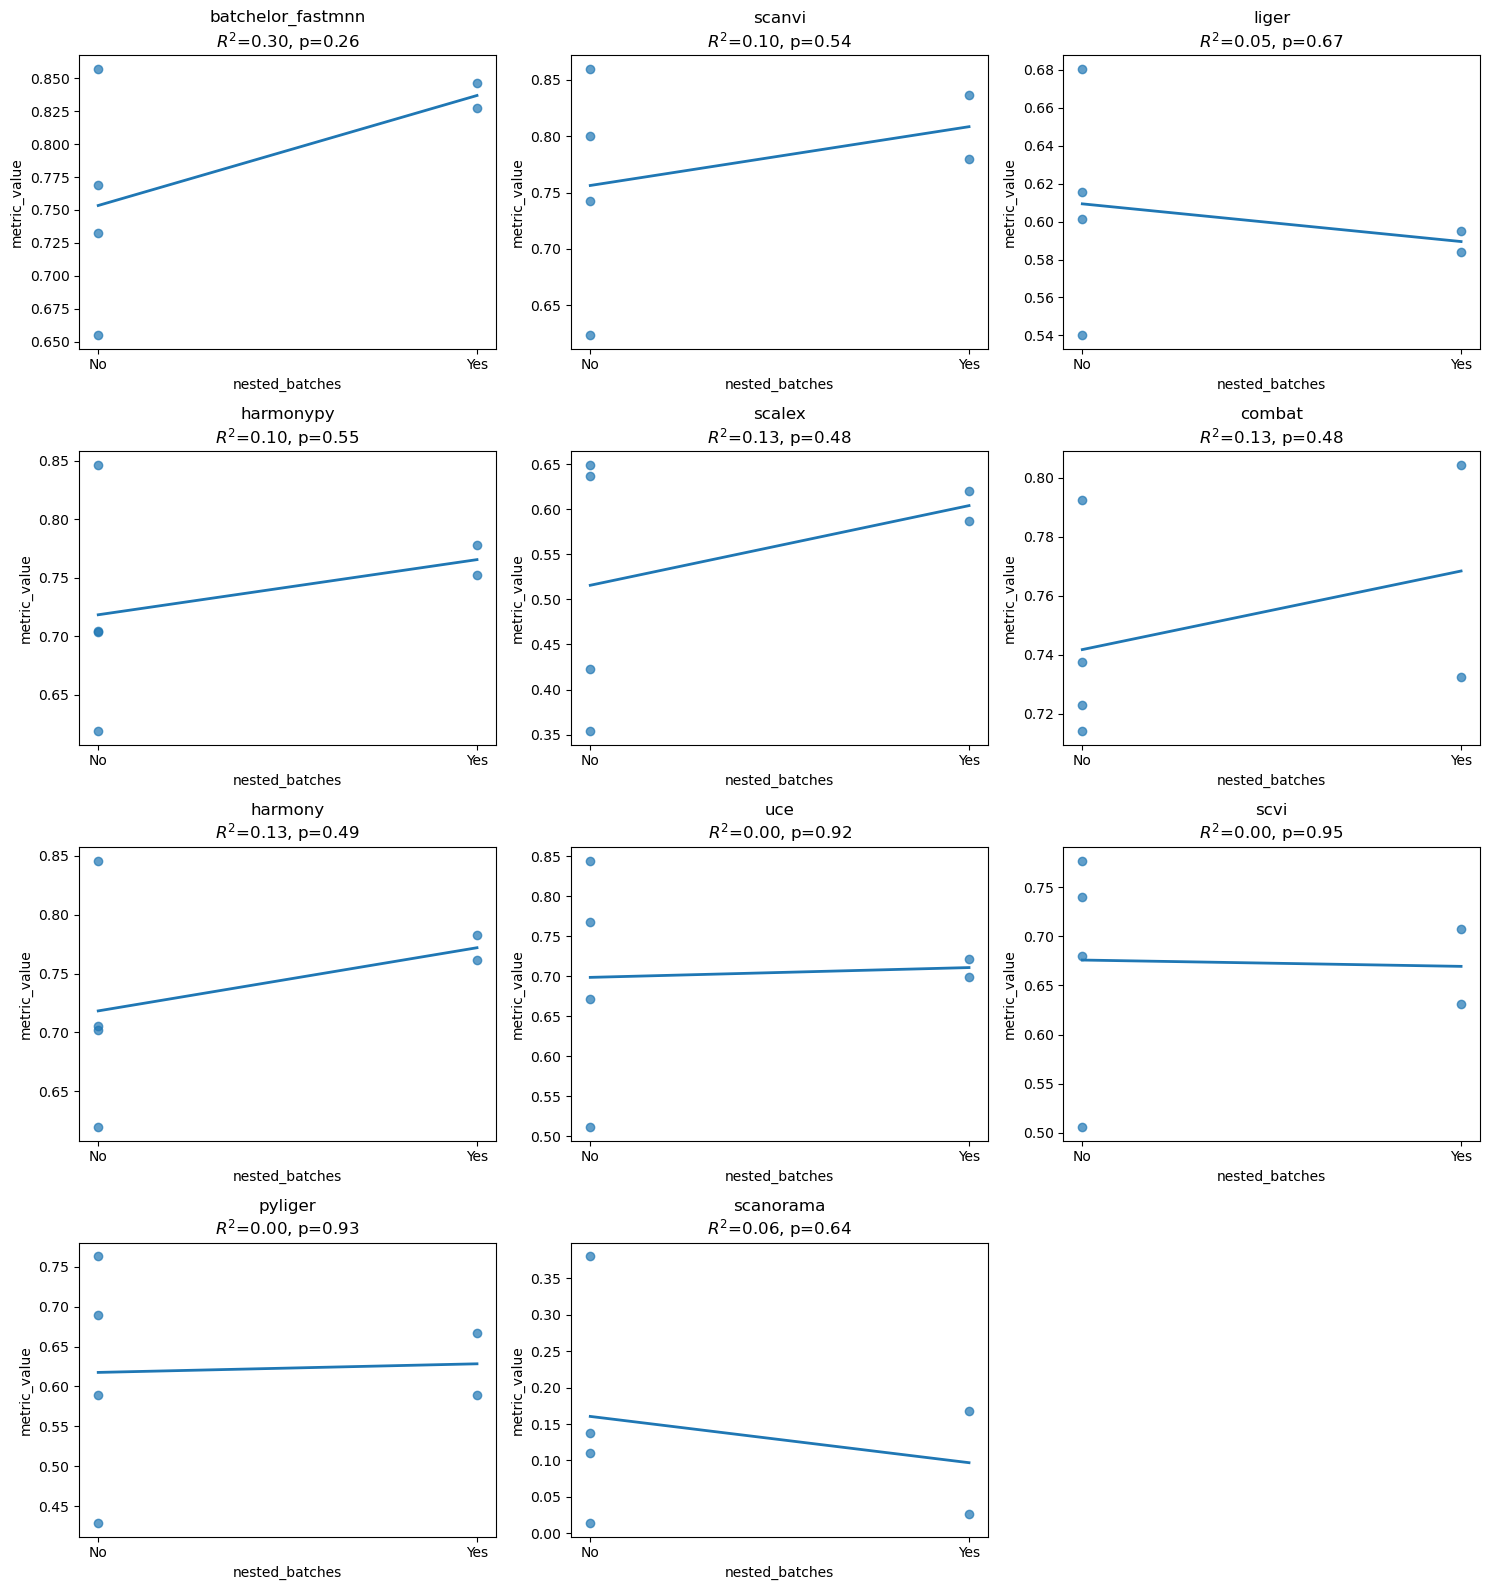

In [18]:
df_metric = df.query("metric_id == 'cell_cycle_conservation'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with asw_label

In [19]:
rows = []

for method, df_m in df.query("metric_id == 'asw_label' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.024397  0.718897  0.035977
1              combat  6 -0.037540  0.469006  0.137656
2             harmony  6 -0.026984  0.728673  0.033462
3           harmonypy  6 -0.022442  0.769569  0.023981
4               liger  6 -0.068489  0.466848  0.138898
5             pyliger  6 -0.059514  0.537809  0.101724
6              scalex  6 -0.052907  0.423733  0.165309
7           scanorama  6  0.017625  0.748645  0.028623
8              scanvi  6  0.021062  0.570910  0.086778
9                scvi  6 -0.003162  0.891925  0.005209
10                uce  6 -0.013723  0.674372  0.048694


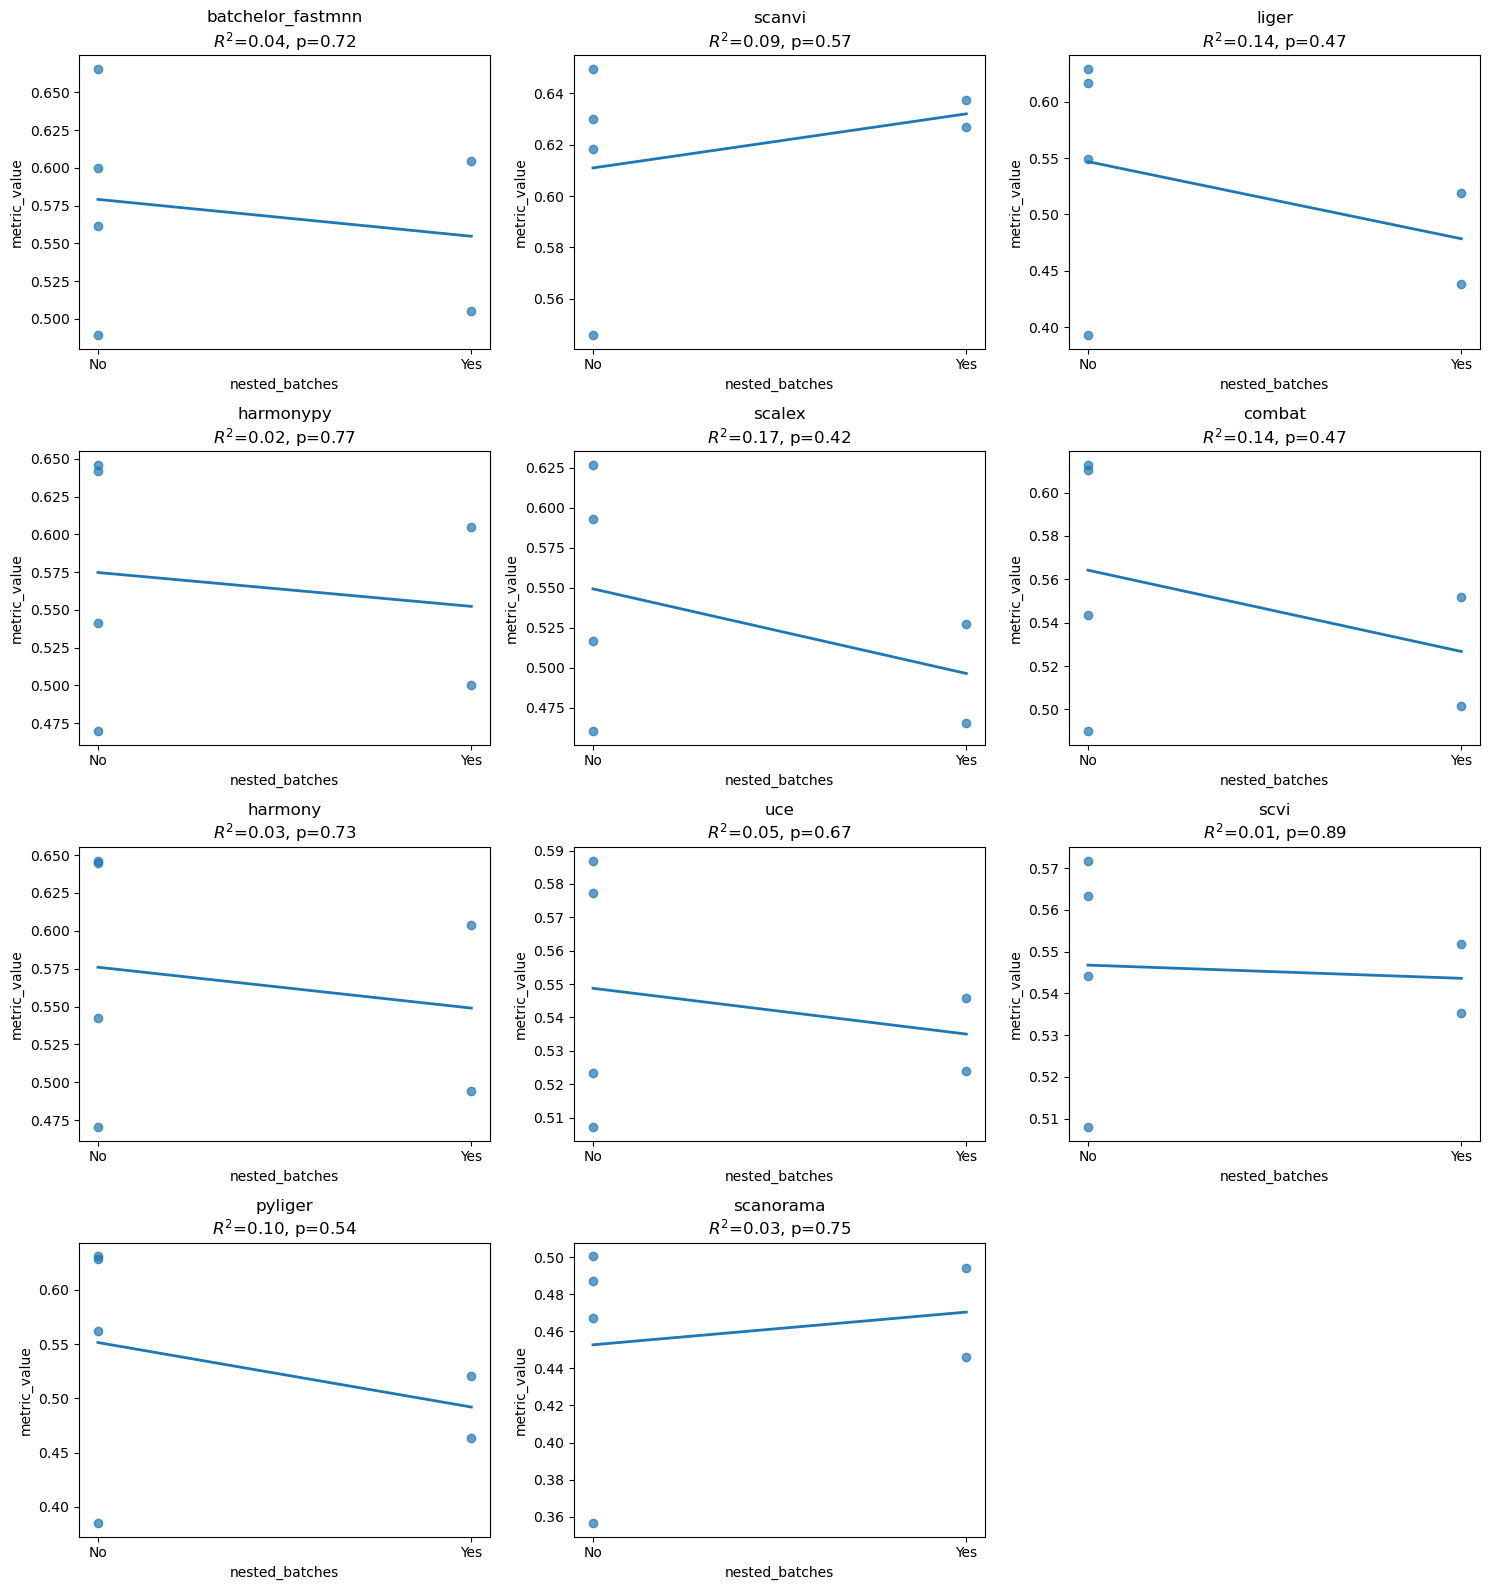

In [20]:
df_metric = df.query("metric_id == 'asw_label'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with isolated_label_f1

In [21]:
rows = []

for method, df_m in df.query("metric_id == 'isolated_label_f1' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  5  0.423755  0.269307  0.378568
1              combat  5  0.379659  0.197391  0.475927
2             harmony  5  0.026507  0.340737  0.298478
3           harmonypy  5  0.057676  0.041154  0.798011
4               liger  5  0.075034  0.080055  0.693379
5             pyliger  5  0.060653  0.150727  0.551173
6              scalex  5  0.027425  0.233878  0.424111
7           scanorama  5 -0.007124  0.682058  0.063715
8              scanvi  5  0.482906  0.233741  0.424295
9                scvi  5  0.481345  0.211969  0.454569
10                uce  5  0.037084  0.339731  0.299510


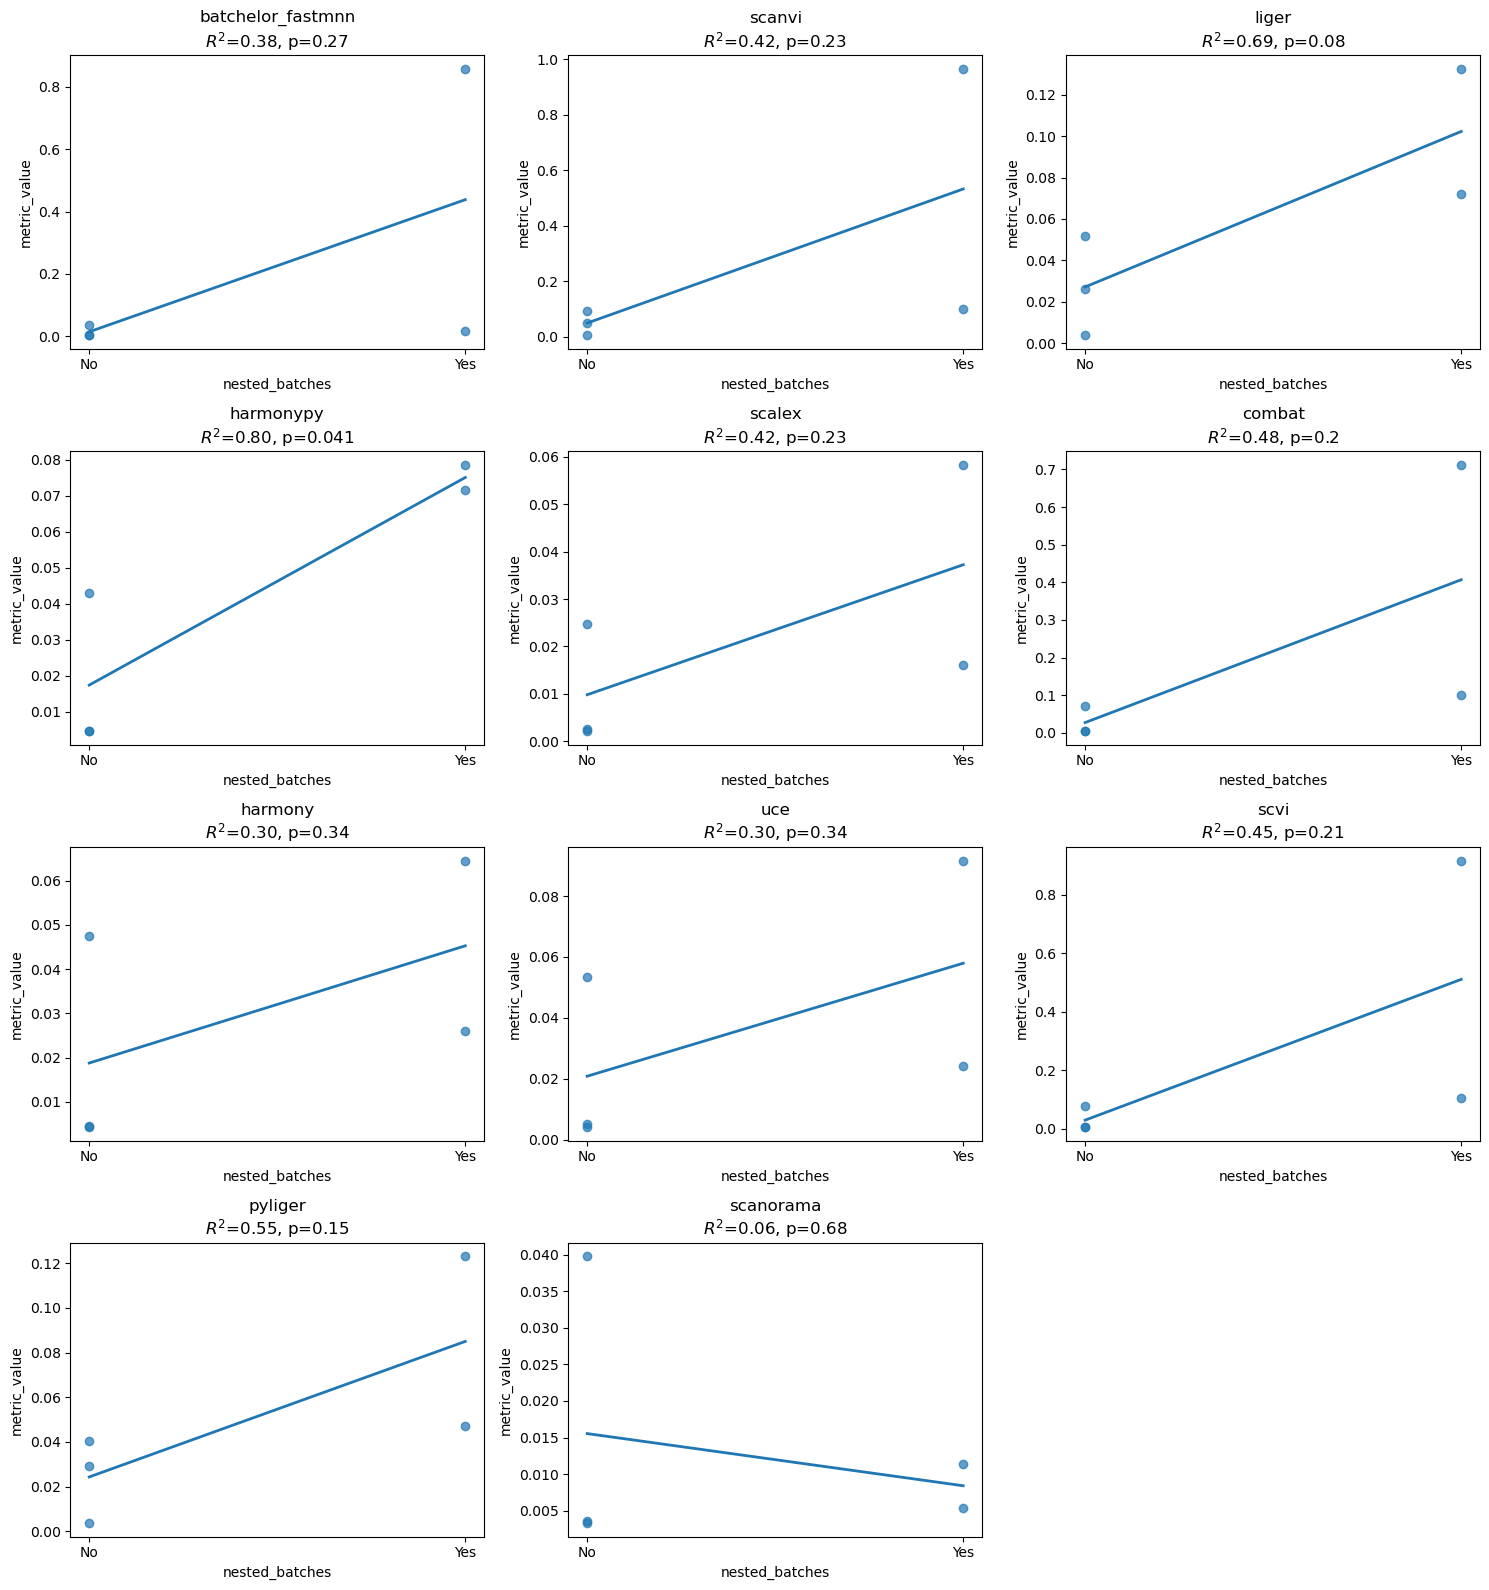

In [22]:
df_metric = df.query("metric_id == 'isolated_label_f1'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with isolated_label_asw

In [23]:
rows = []

for method, df_m in df.query("metric_id == 'isolated_label_asw' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  5  0.223254  0.231896  0.426790
1              combat  5  0.163396  0.229684  0.429796
2             harmony  5  0.184646  0.219487  0.443904
3           harmonypy  5  0.179356  0.223699  0.438028
4               liger  5  0.233371  0.023860  0.857610
5             pyliger  5  0.215619  0.023738  0.858079
6              scalex  5  0.200339  0.206024  0.463168
7           scanorama  5  0.034837  0.272976  0.374091
8              scanvi  5  0.196110  0.221862  0.440581
9                scvi  5  0.141528  0.189763  0.487478
10                uce  5  0.054272  0.547259  0.132330


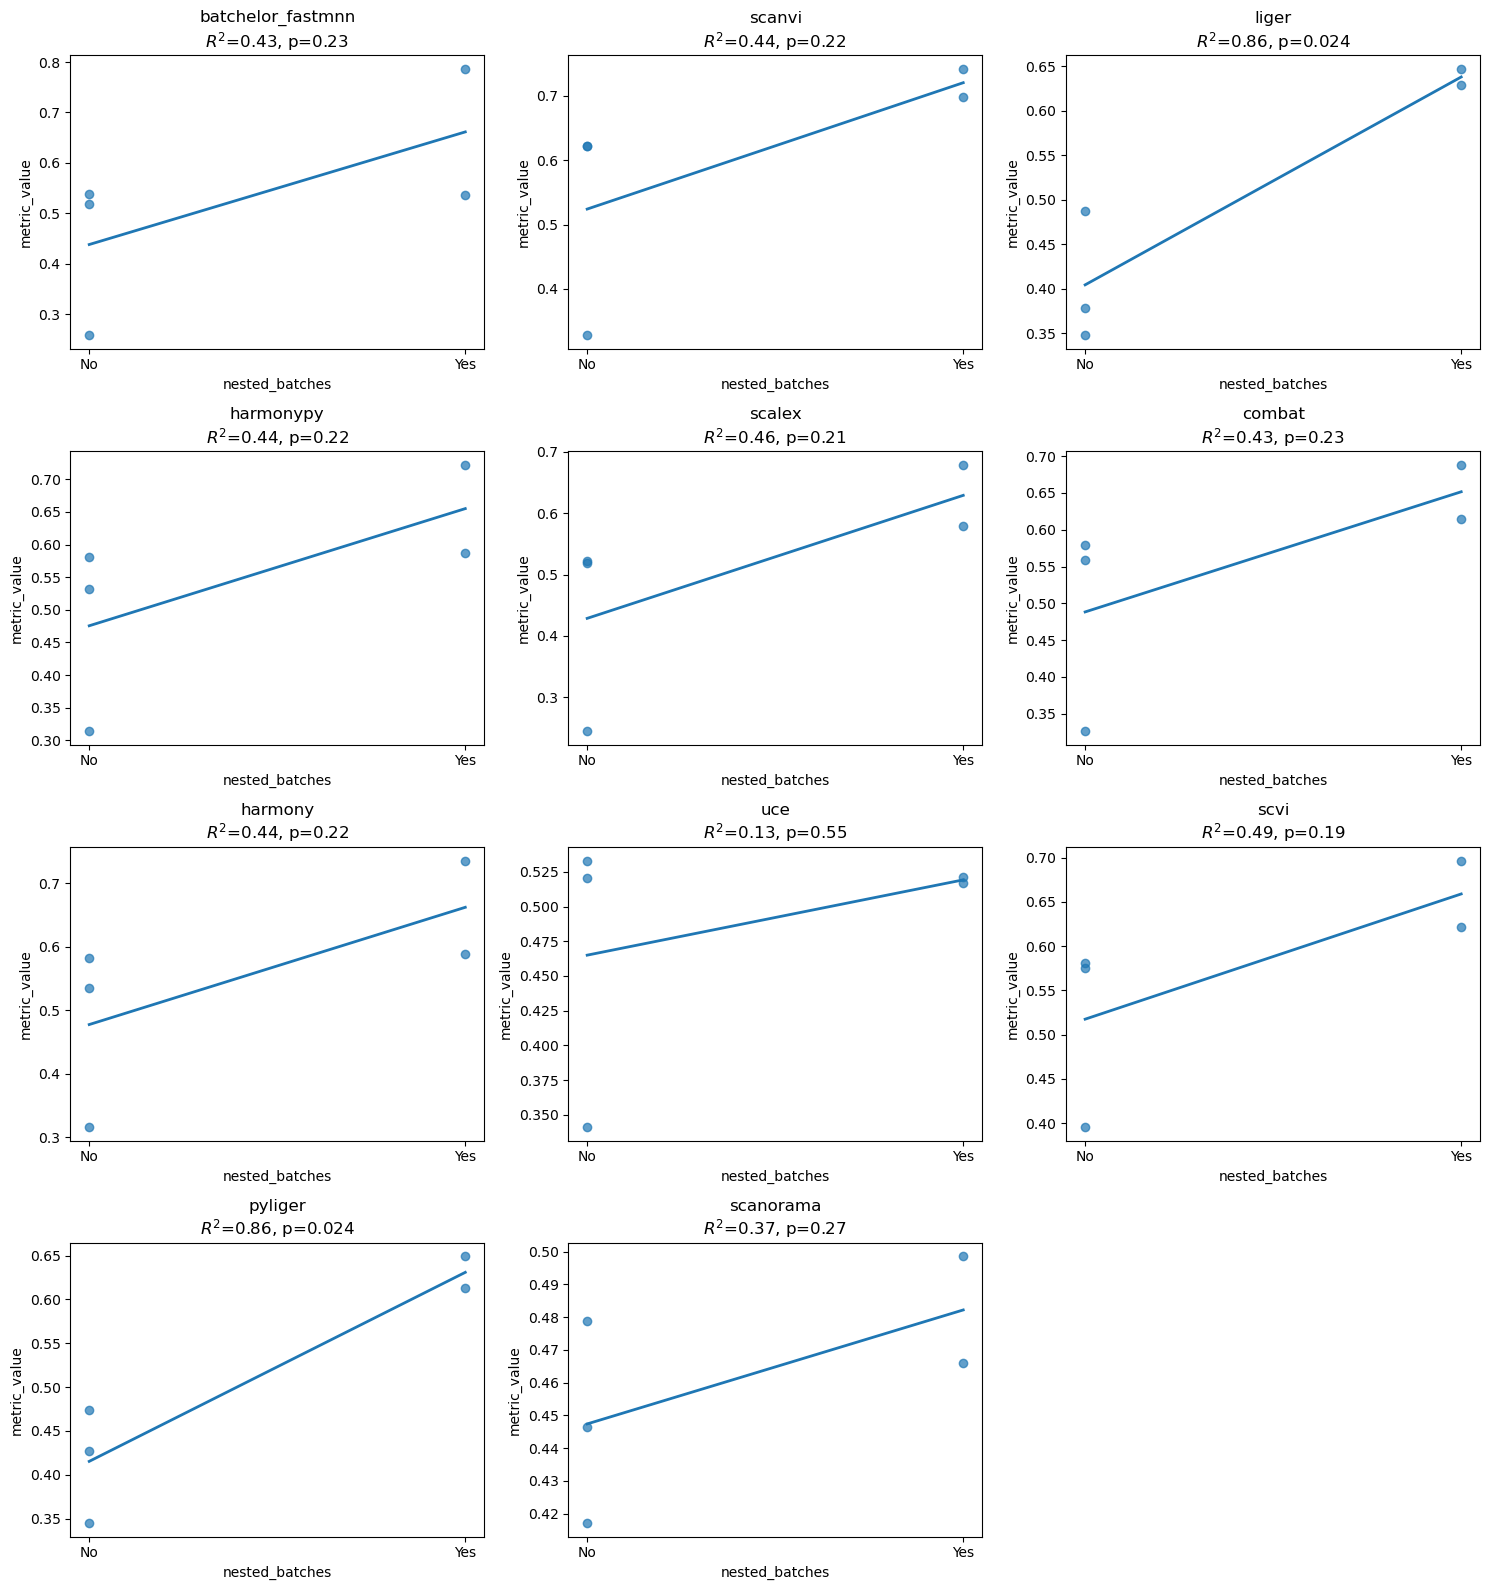

In [24]:
df_metric = df.query("metric_id == 'isolated_label_asw'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with pcr

In [25]:
rows = []

for method, df_m in df.query("metric_id == 'pcr' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.232869  0.147350  0.445724
1              combat  6  0.000135  0.423962  0.165160
2             harmony  6 -0.027589  0.748996  0.028542
3           harmonypy  6 -0.047507  0.626448  0.064786
4               liger  6  0.031127  0.833688  0.012395
5             pyliger  6  0.023279  0.833588  0.012410
6              scalex  6 -0.008810  0.244866  0.316816
7           scanorama  6  0.163500  0.673024  0.049112
8              scanvi  6 -0.182277  0.356642  0.213181
9                scvi  6  0.036397  0.830188  0.012927
10                uce  6 -0.023838  0.657187  0.054170


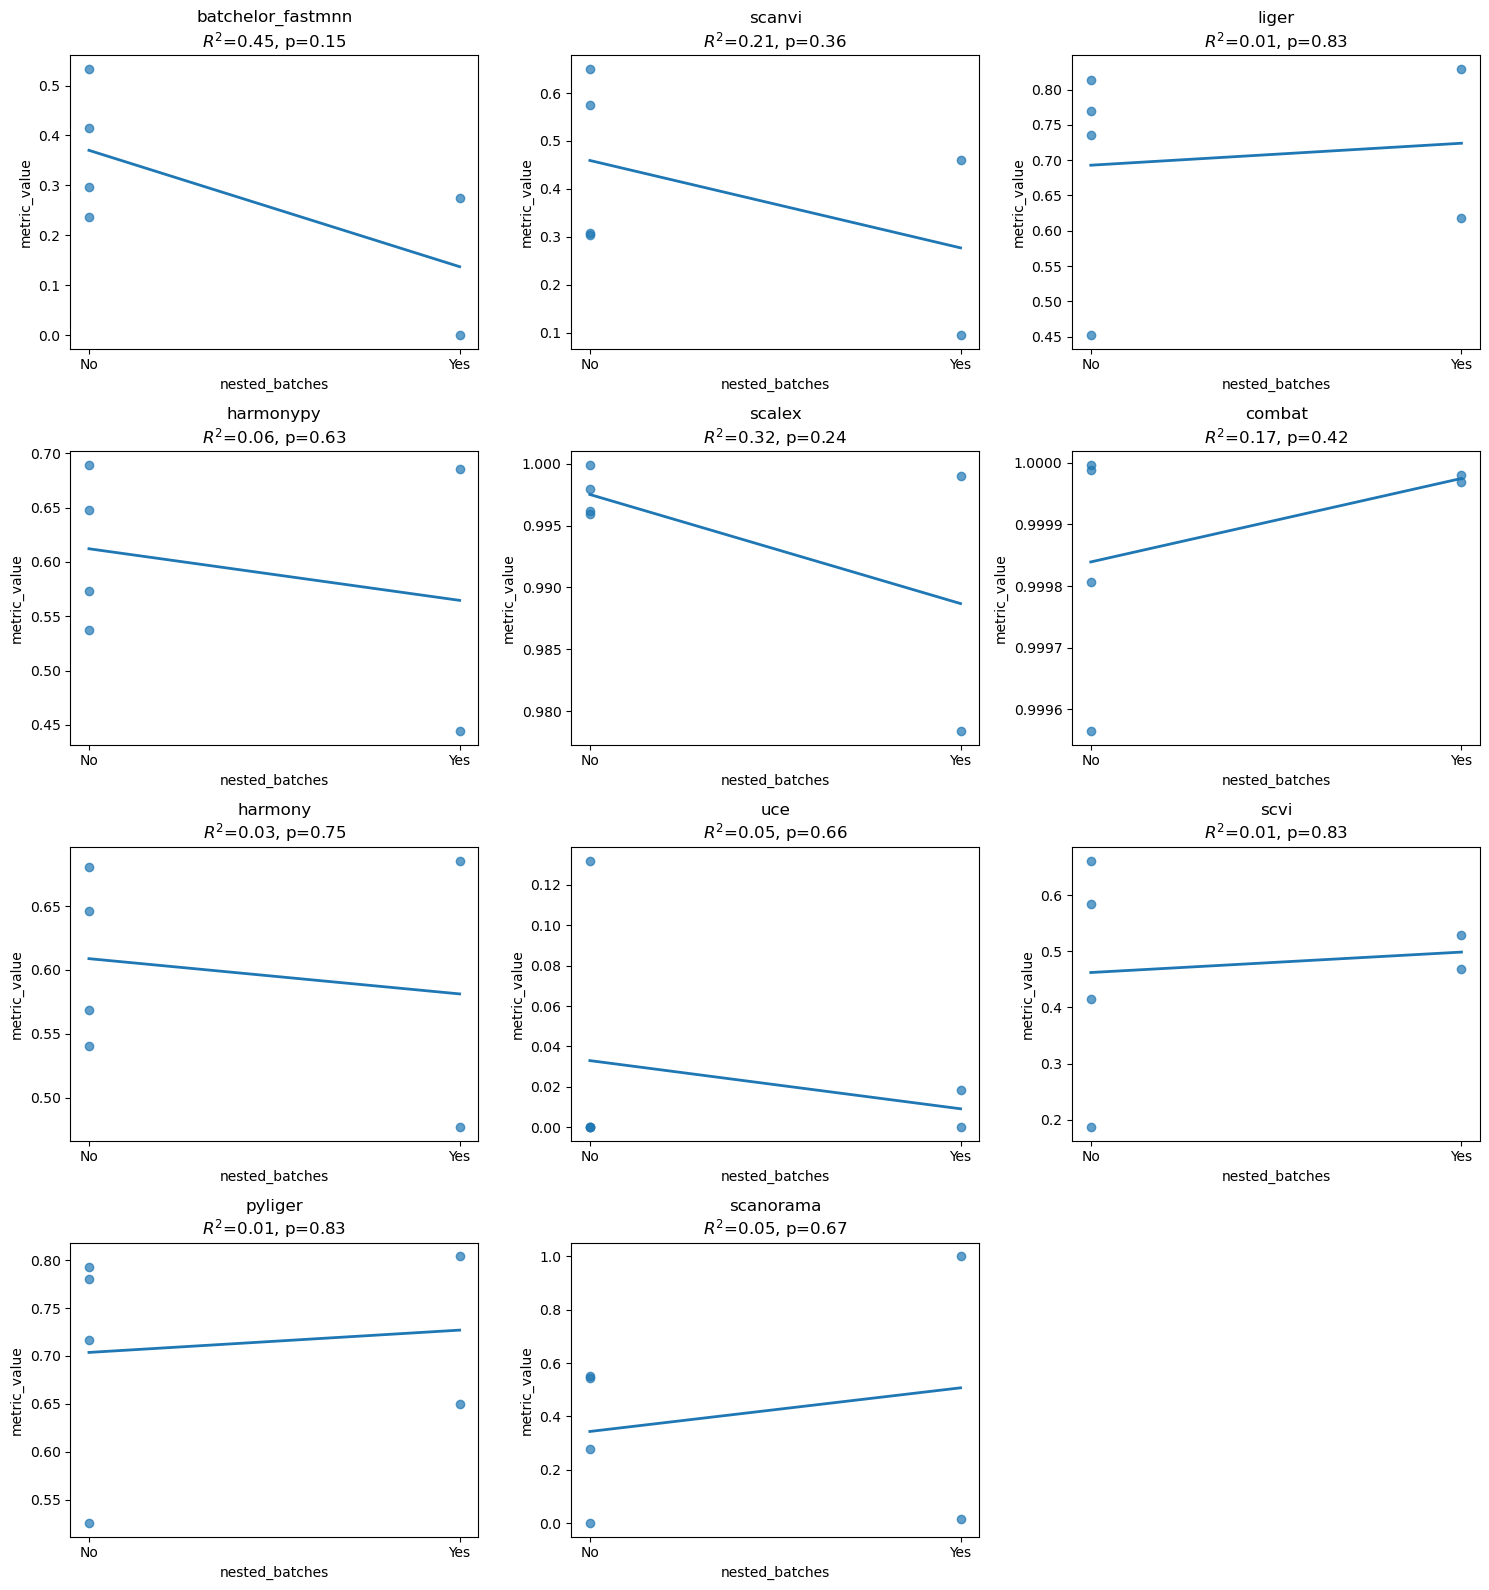

In [26]:
df_metric = df.query("metric_id == 'pcr'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with ilisi

In [27]:
rows = []

for method, df_m in df.query("metric_id == 'ilisi' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.050651  0.614670  0.069141
1              combat  6 -0.027264  0.666665  0.051110
2             harmony  6 -0.025975  0.832133  0.012630
3           harmonypy  6 -0.037254  0.759787  0.026098
4               liger  6 -0.029516  0.845015  0.010753
5             pyliger  6 -0.026810  0.860578  0.008690
6              scalex  6 -0.035574  0.755303  0.027099
7           scanorama  6  0.009410  0.928461  0.002278
8              scanvi  6 -0.053542  0.659190  0.053515
9                scvi  6 -0.062267  0.597960  0.075600
10                uce  6 -0.031706  0.705917  0.039469


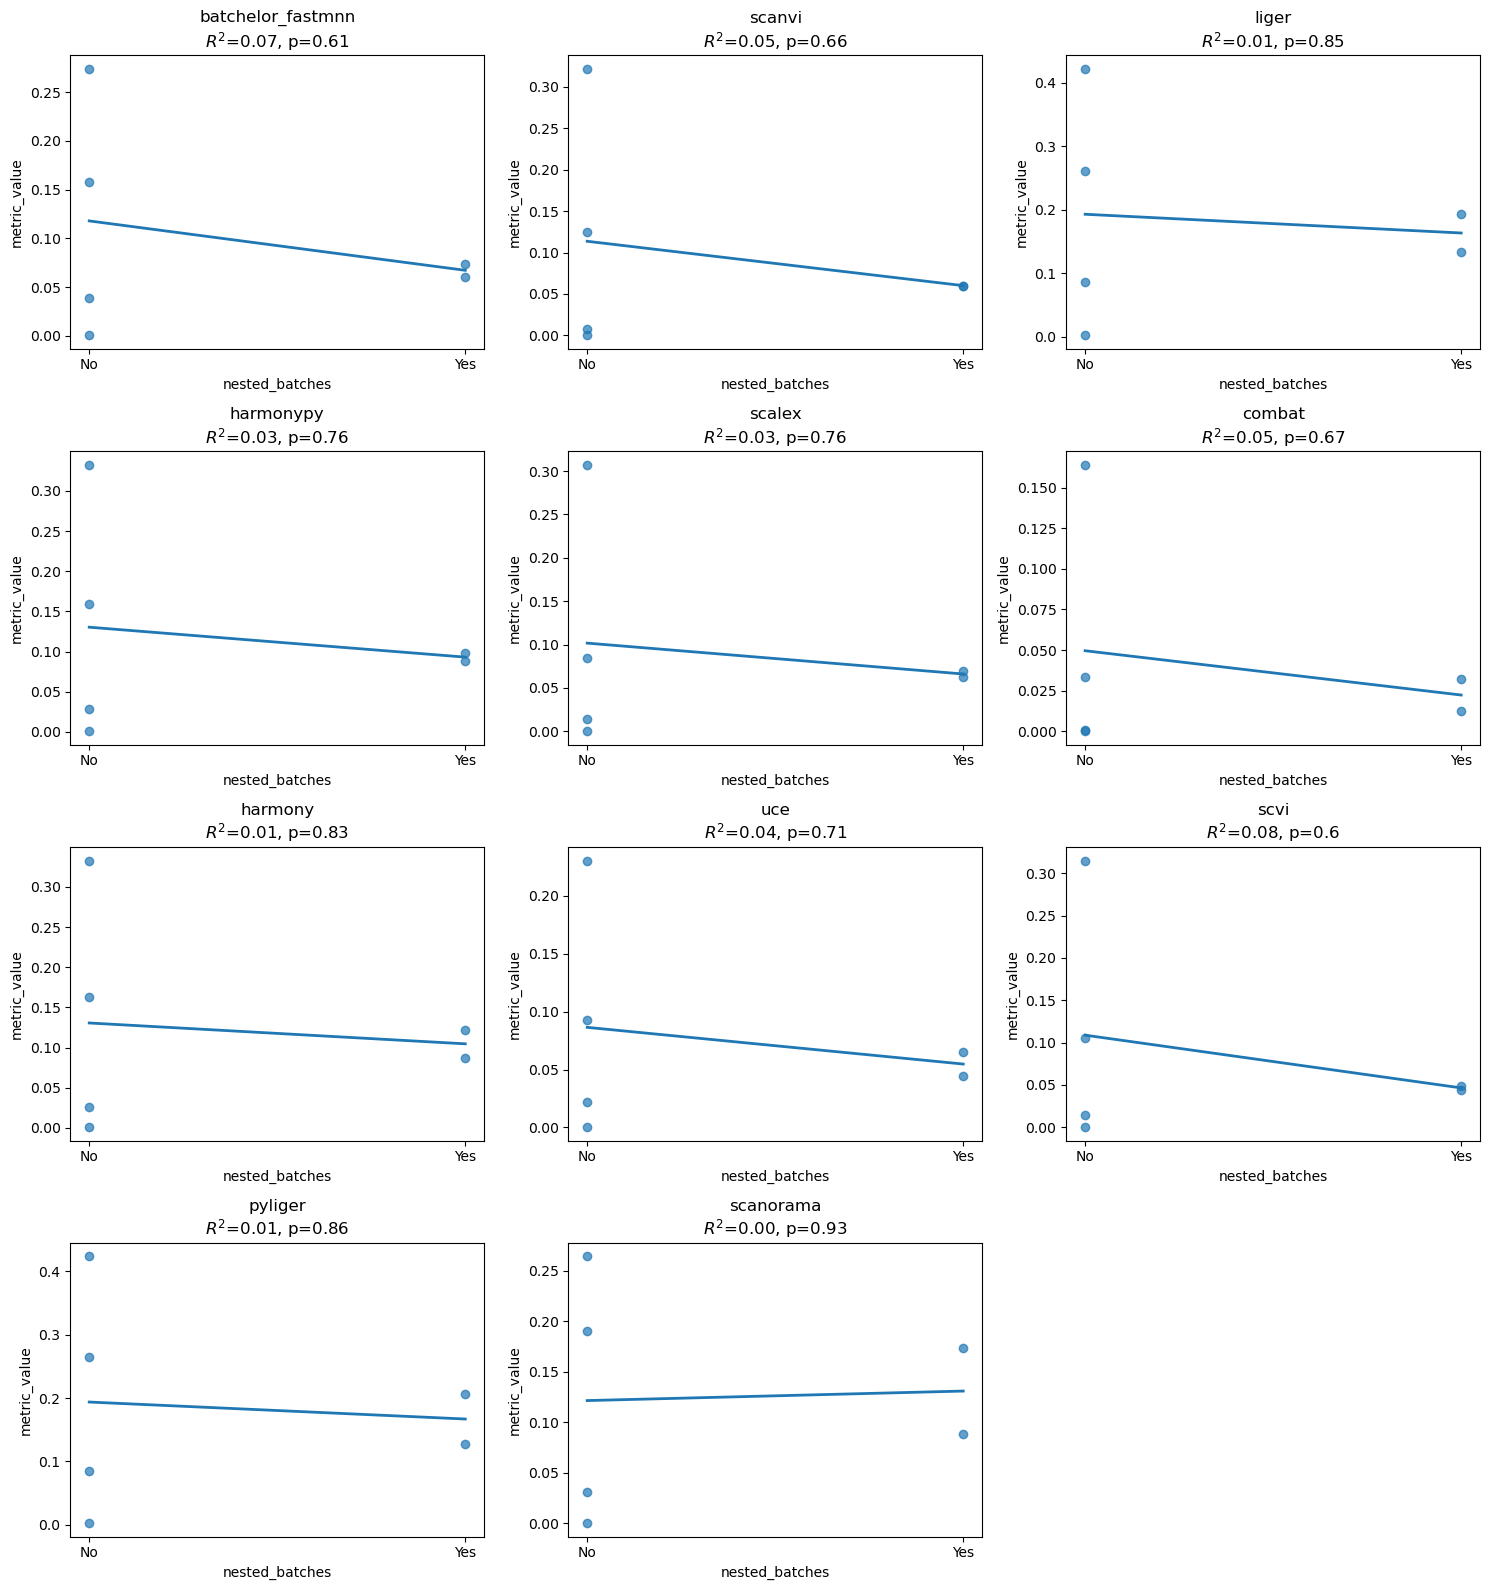

In [28]:
df_metric = df.query("metric_id == 'ilisi'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with clisi

In [29]:
rows = []

for method, df_m in df.query("metric_id == 'clisi' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.000881  0.644684  0.058359
1              combat  6  0.001079  0.583481  0.081471
2             harmony  6 -0.000104  0.970993  0.000374
3           harmonypy  6  0.001036  0.696389  0.042145
4               liger  6 -0.006129  0.338022  0.228142
5             pyliger  6 -0.005674  0.389812  0.188399
6              scalex  6 -0.001102  0.890698  0.005329
7           scanorama  6 -0.069371  0.446661  0.150876
8              scanvi  6  0.000099  0.391601  0.187127
9                scvi  6  0.000868  0.457084  0.144608
10                uce  6  0.001766  0.572887  0.085930


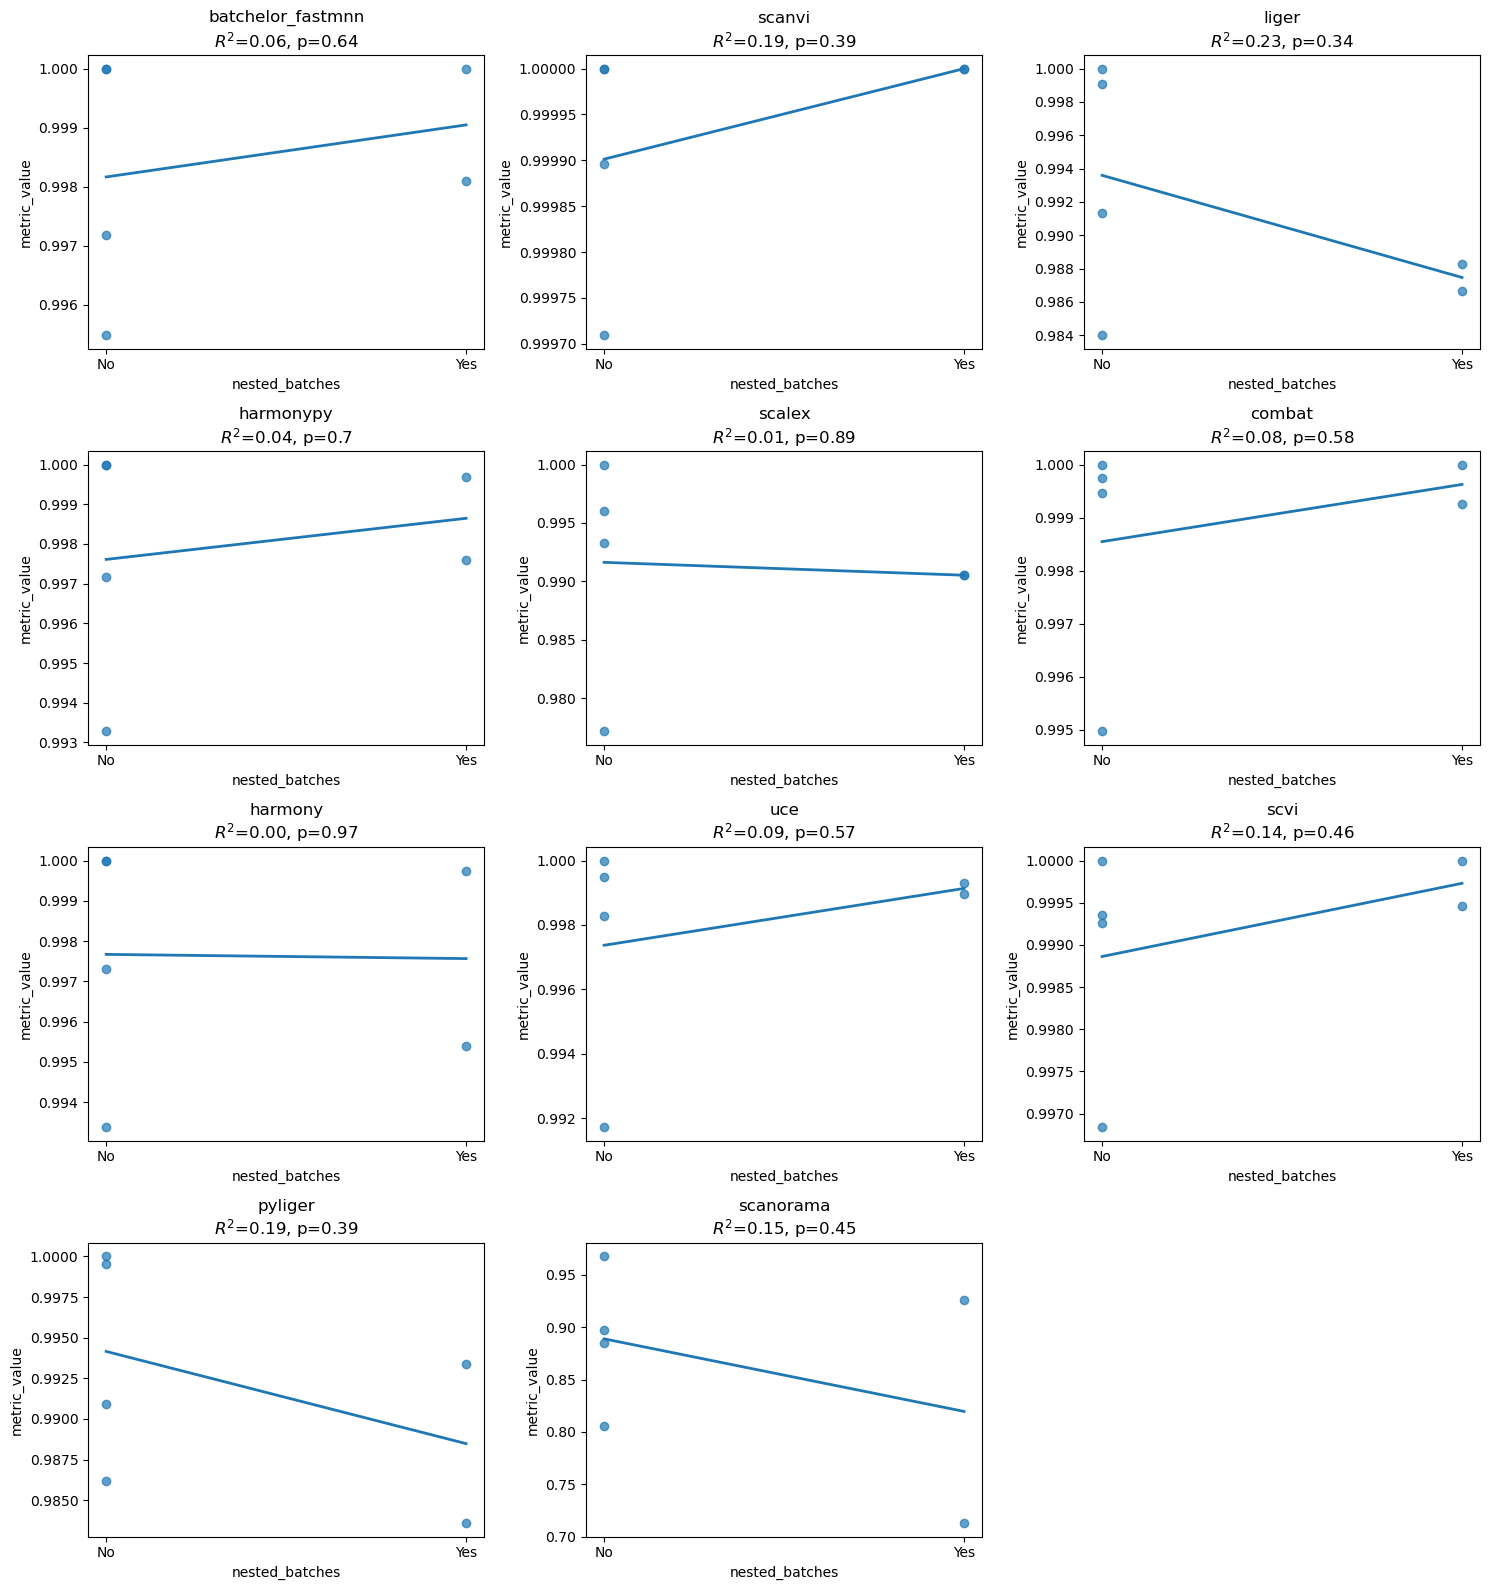

In [30]:
df_metric = df.query("metric_id == 'clisi'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with asw_batch

In [31]:
rows = []

for method, df_m in df.query("metric_id == 'asw_batch' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.006305  0.808952  0.016401
1              combat  6  0.014858  0.736918  0.031415
2             harmony  6 -0.015391  0.745347  0.029395
3           harmonypy  6 -0.013833  0.771116  0.023655
4               liger  6 -0.073545  0.339676  0.226780
5             pyliger  6 -0.043598  0.596125  0.076330
6              scalex  6 -0.013772  0.646242  0.057828
7           scanorama  6 -0.002489  0.967633  0.000466
8              scanvi  6  0.005228  0.899001  0.004547
9                scvi  6  0.015847  0.667160  0.050953
10                uce  6  0.008759  0.575971  0.084617


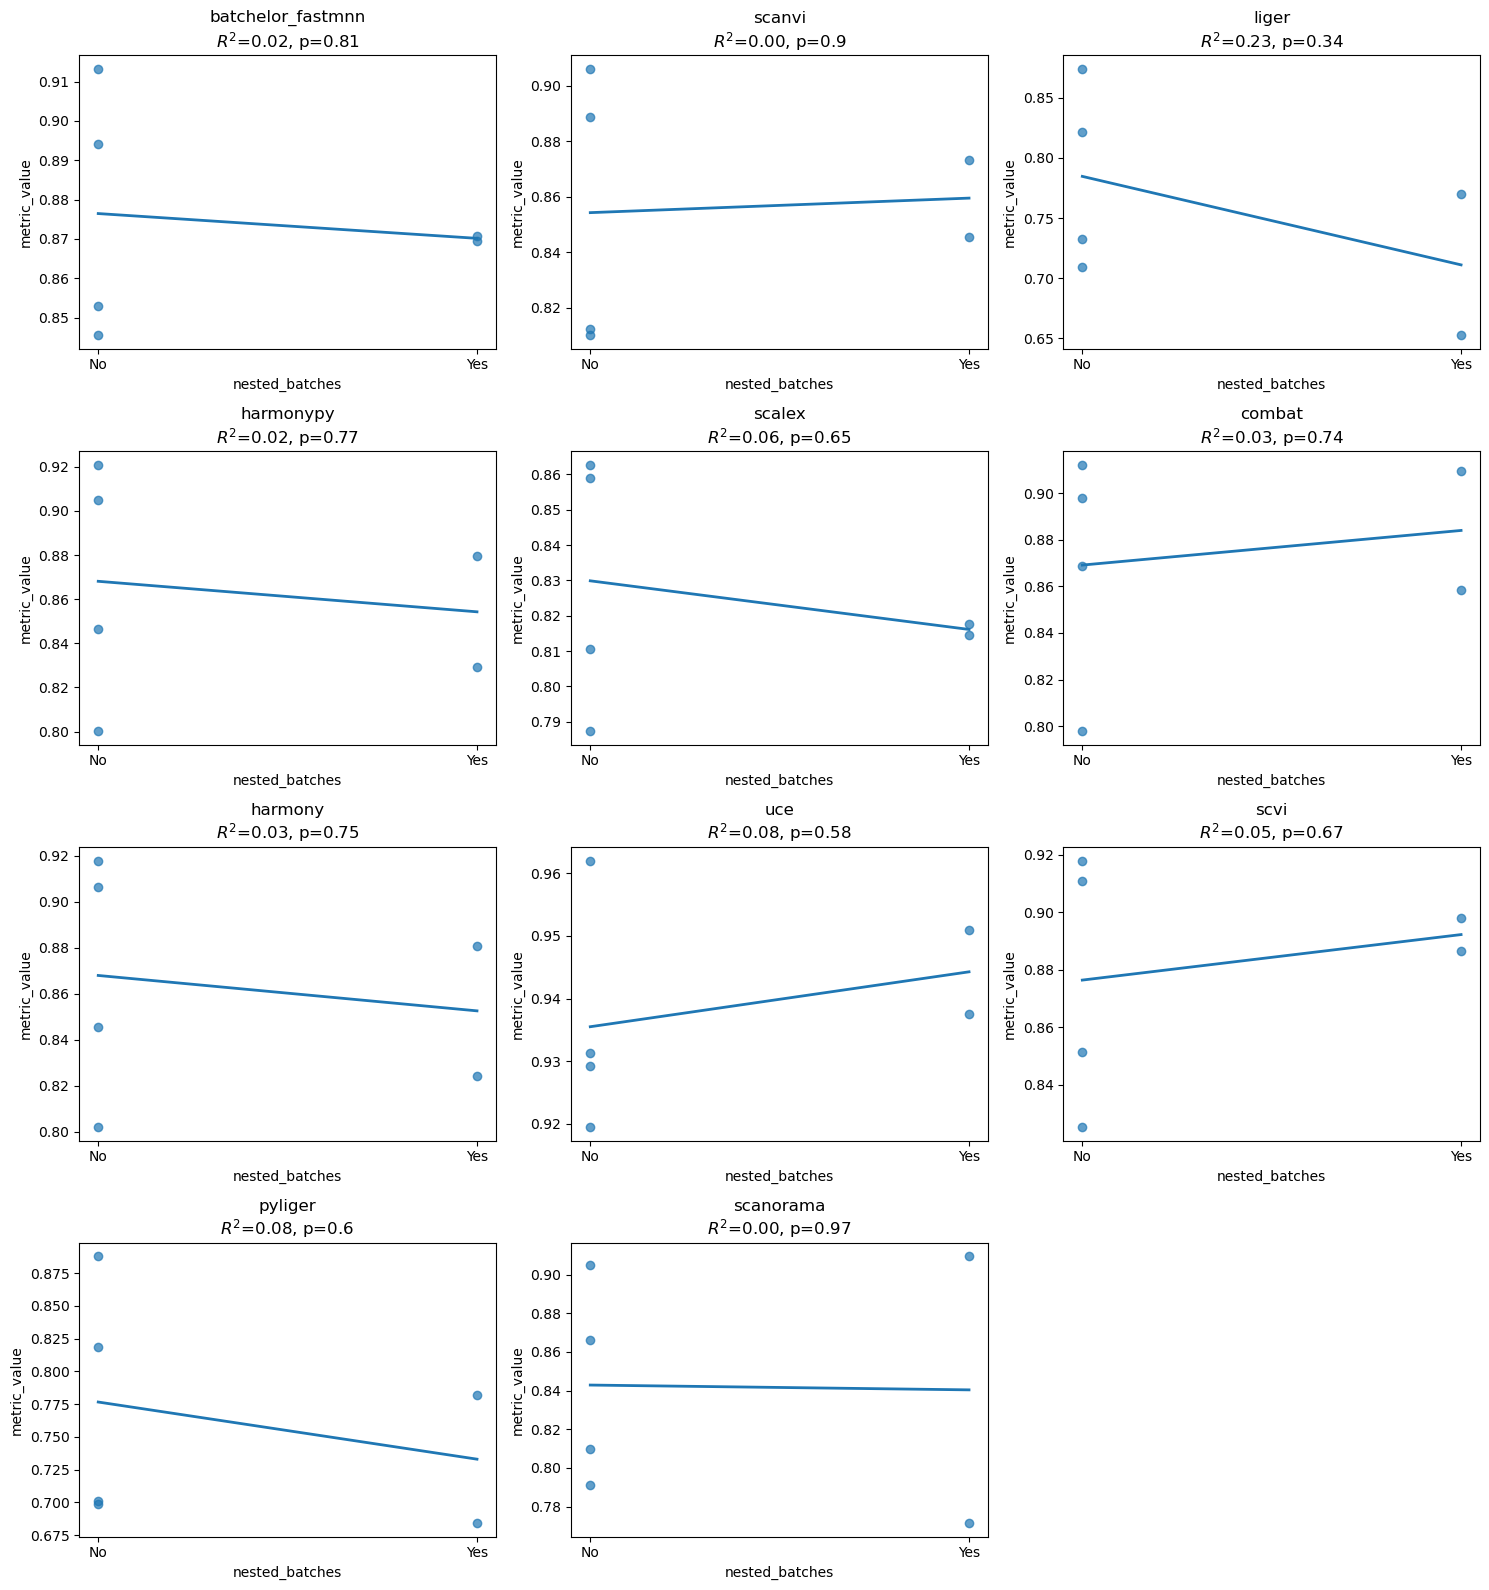

In [32]:
df_metric = df.query("metric_id == 'asw_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with kbet_pg

In [33]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.240818  0.485532  0.128388
1              combat  6 -0.229509  0.539081  0.101123
2             harmony  6 -0.229687  0.487999  0.127041
3           harmonypy  6 -0.232494  0.482998  0.129782
4               liger  6 -0.305621  0.238845  0.323497
5             pyliger  6 -0.319029  0.222586  0.342242
6              scalex  6 -0.237112  0.514655  0.113053
7           scanorama  6  0.219627  0.634352  0.061954
8              scanvi  6 -0.224527  0.510351  0.115242
9                scvi  6 -0.230713  0.504606  0.118205
10                uce  6 -0.228499  0.520515  0.110116


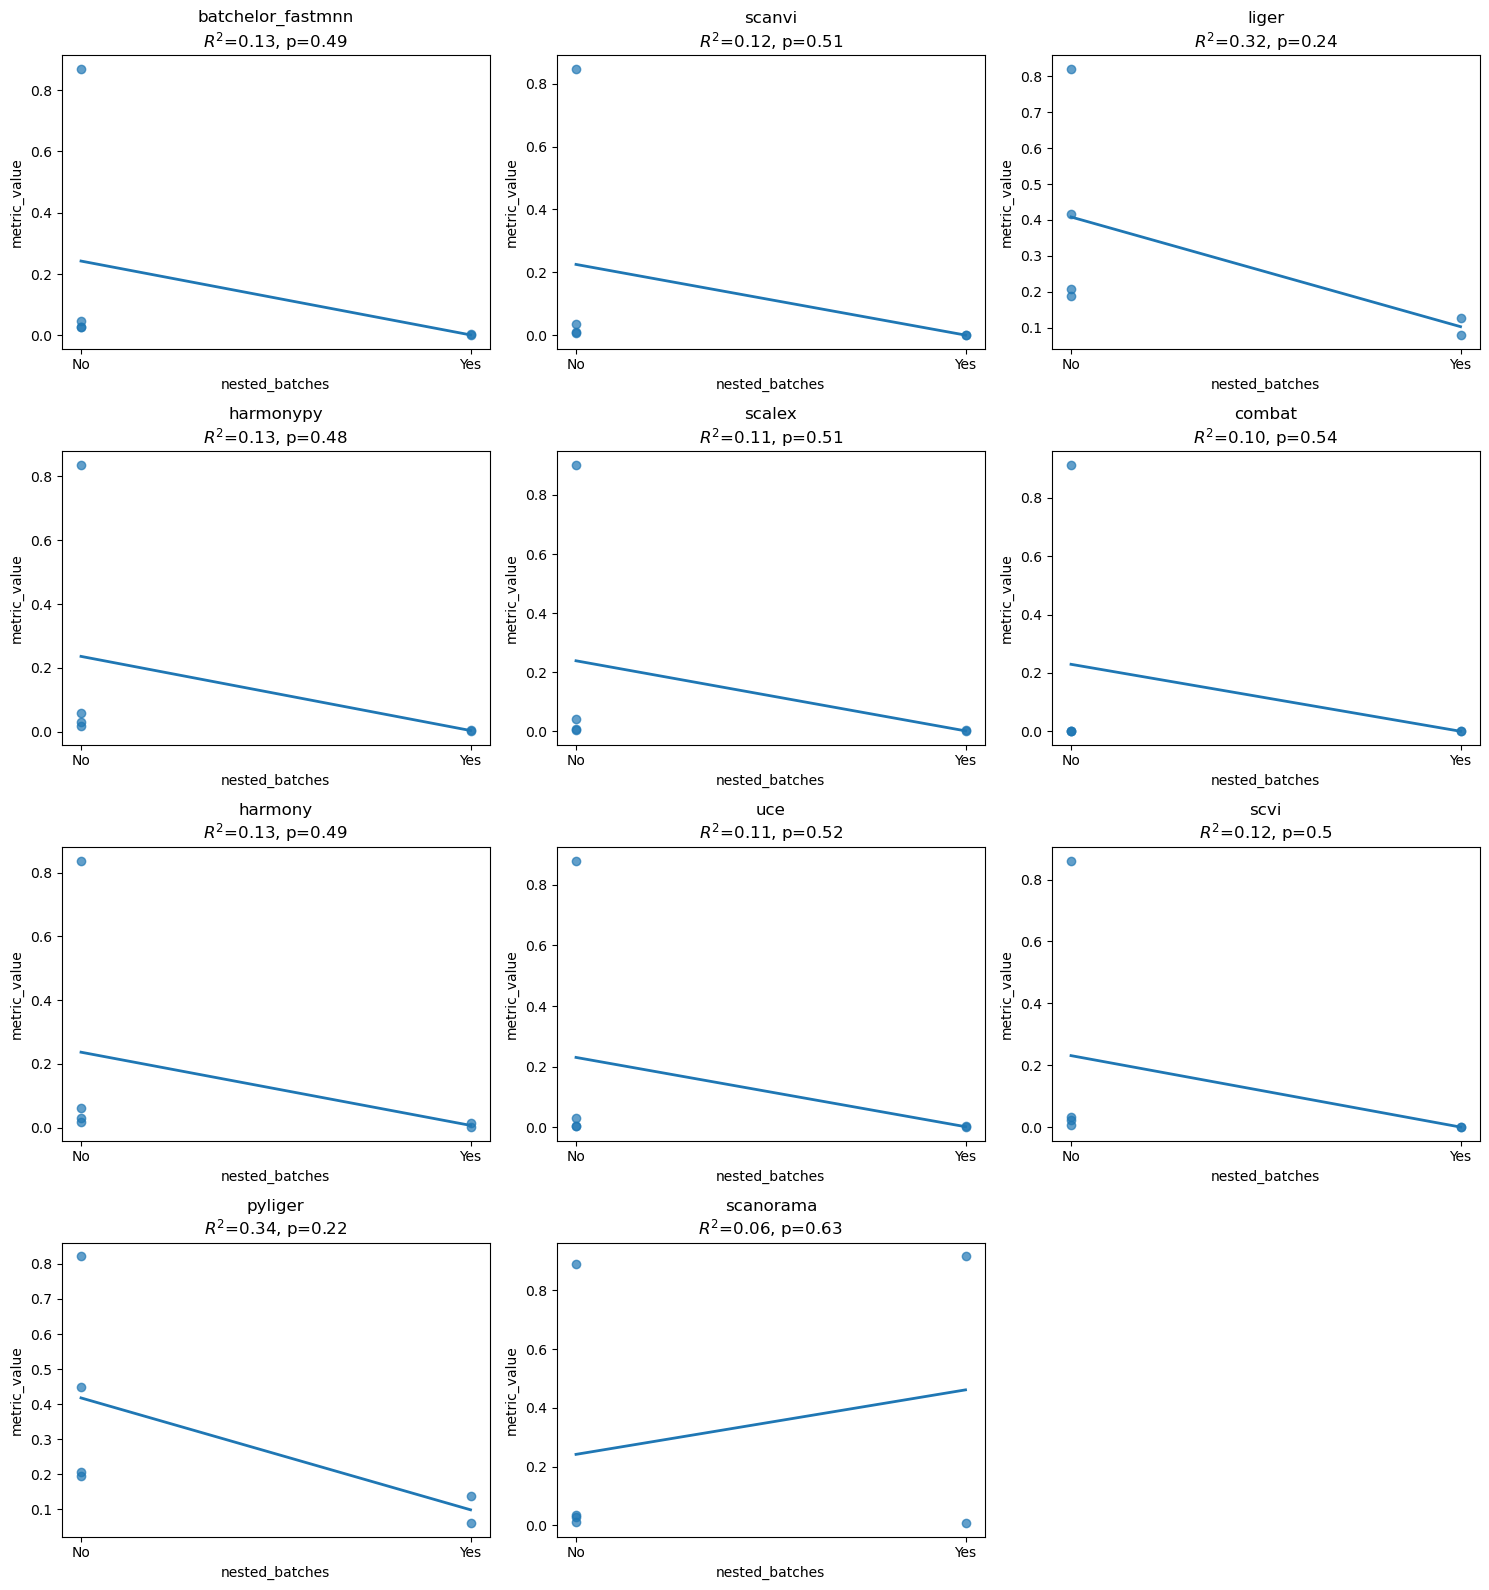

In [34]:
df_metric = df.query("metric_id == 'kbet_pg'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with kbet_pg_label

In [35]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg_label' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.166528  0.439069  0.155555
1              combat  6 -0.217708  0.497986  0.121678
2             harmony  6 -0.149039  0.499318  0.120974
3           harmonypy  6 -0.148263  0.493083  0.124293
4               liger  6 -0.092198  0.621827  0.066476
5             pyliger  6 -0.110674  0.572795  0.085969
6              scalex  6 -0.211227  0.474072  0.134770
7           scanorama  6  0.170243  0.615801  0.068716
8              scanvi  6 -0.136971  0.593245  0.077484
9                scvi  6 -0.175486  0.514129  0.113320
10                uce  6 -0.150327  0.608178  0.071611


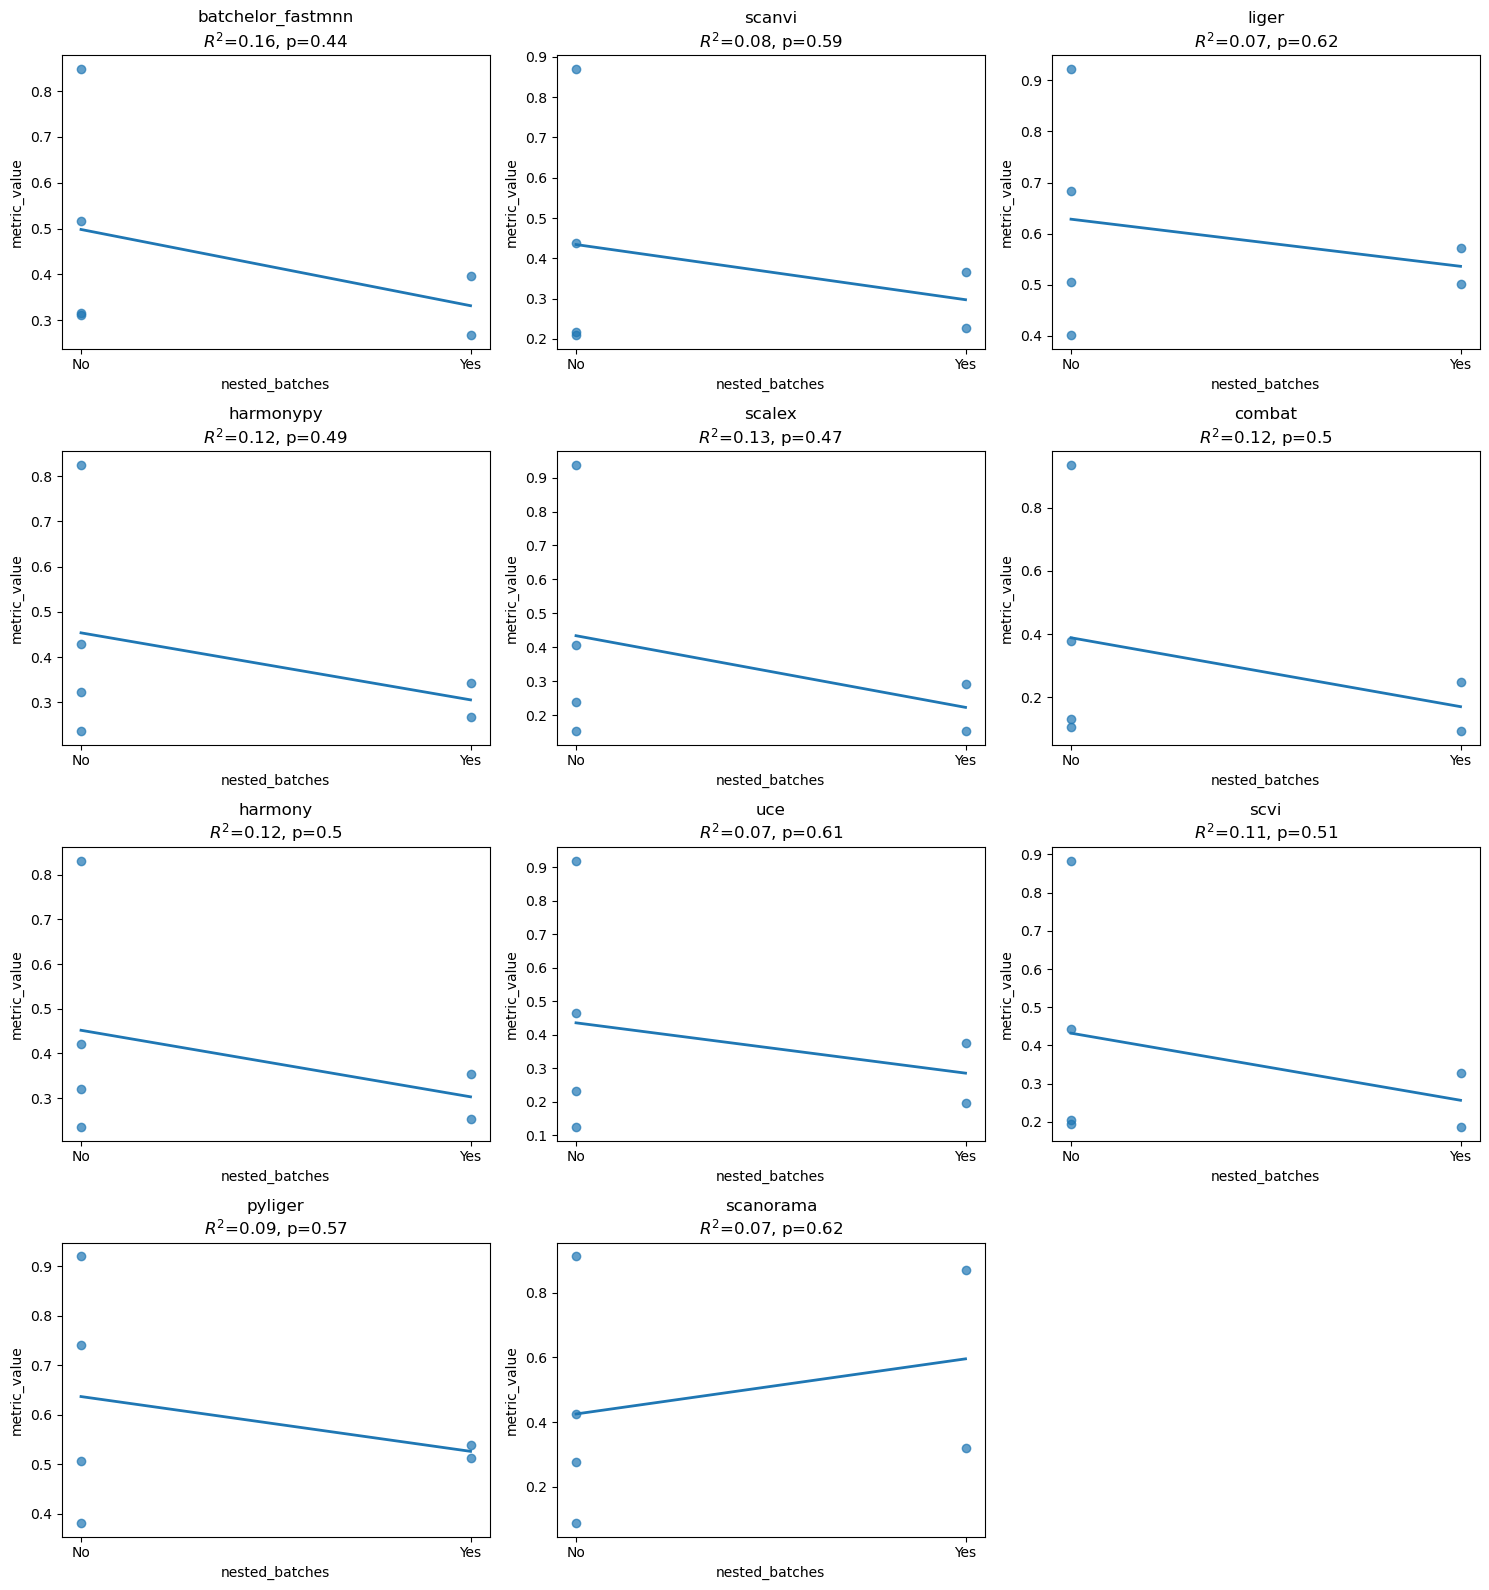

In [36]:
df_metric = df.query("metric_id == 'kbet_pg_label'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with ari_batch

In [38]:
rows = []

for method, df_m in df.query("metric_id == 'ari_batch' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.074130  0.026446  0.746679
1              combat  6 -0.067908  0.050223  0.657667
2             harmony  6 -0.022961  0.342185  0.224728
3           harmonypy  6 -0.028694  0.323254  0.240591
4               liger  6 -0.012646  0.480322  0.131265
5             pyliger  6 -0.008420  0.593615  0.077335
6              scalex  6 -0.022262  0.125389  0.482958
7           scanorama  6 -0.019476  0.563043  0.090201
8              scanvi  6 -0.046691  0.173445  0.406188
9                scvi  6 -0.044460  0.185564  0.389269
10                uce  6 -0.040493  0.364177  0.207347


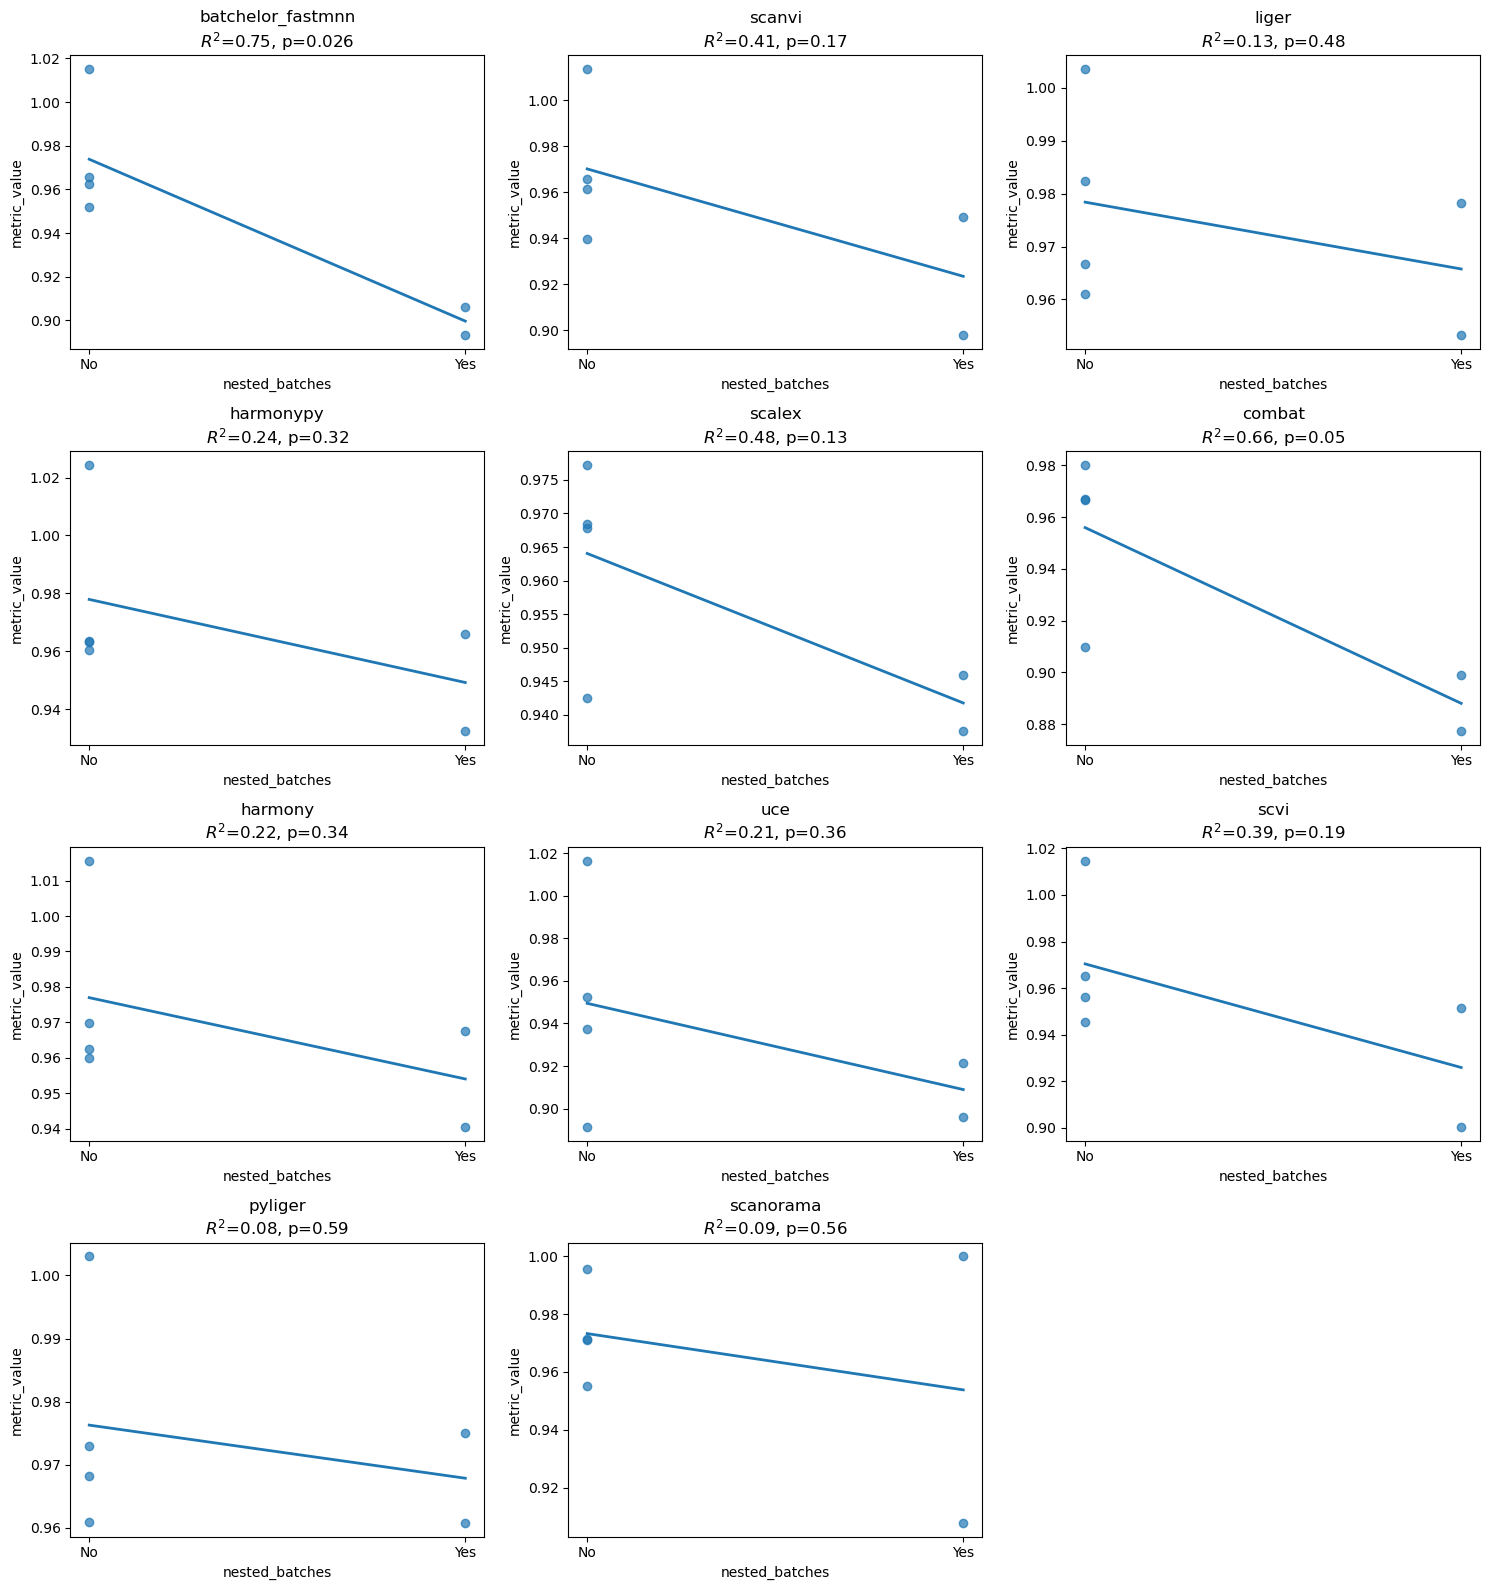

In [37]:
df_metric = df.query("metric_id == 'ari_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with nmi_batch

In [39]:
rows = []

for method, df_m in df.query("metric_id == 'nmi_batch' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.179462  0.072193  0.595621
1              combat  6 -0.181849  0.209350  0.358317
2             harmony  6 -0.101149  0.133614  0.468529
3           harmonypy  6 -0.114789  0.100971  0.529867
4               liger  6 -0.075201  0.076010  0.586058
5             pyliger  6 -0.074471  0.106466  0.518716
6              scalex  6 -0.108556  0.175471  0.403300
7           scanorama  6 -0.013984  0.910696  0.003553
8              scanvi  6 -0.145767  0.245871  0.315713
9                scvi  6 -0.149392  0.162762  0.421826
10                uce  6 -0.136056  0.197982  0.372759


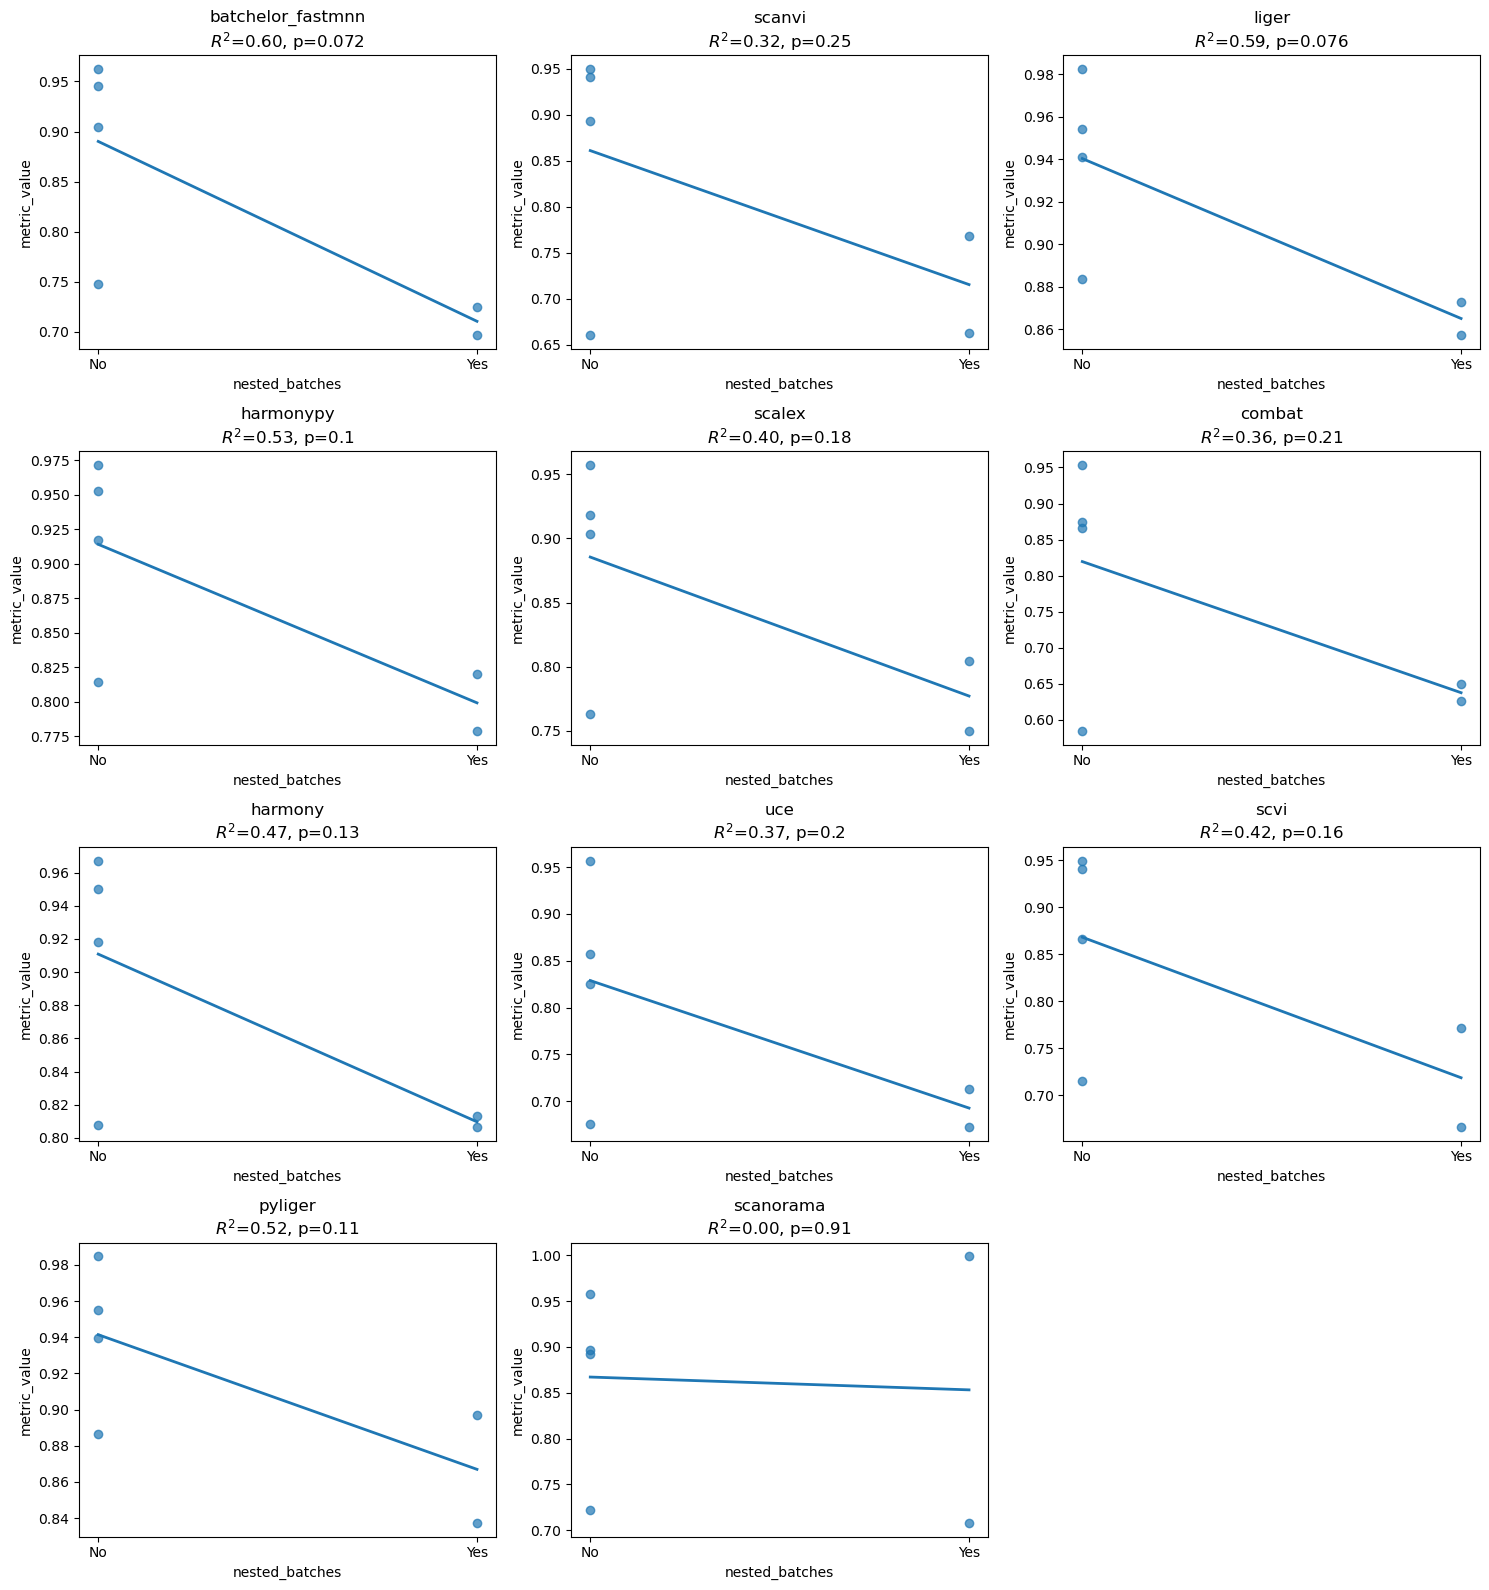

In [40]:
df_metric = df.query("metric_id == 'nmi_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()